In [1]:
from sklearn.datasets import load_diabetes
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, log_loss,
    mean_squared_error, roc_curve
)
from scipy.stats import chi2_contingency, fisher_exact
from scipy import stats
from imblearn.over_sampling import RandomOverSampler
from io import StringIO
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import numpy as np
import pandas as pd

# Risk Score Model Demo

This notebook walks through the end-to-end pipeline for building a clinical risk scoring model using the [diabetes dataset](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt).

The pipeline covers:
1. **Data Preparation** — loading, binarizing, categorizing, splitting, and encoding
2. **Feature Selection** — backward stepwise selection using AIC
3. **GLM Model** — logistic regression training, evaluation, and statistical analysis
4. **Risk Scoring** — converting model coefficients into an interpretable 0–100 risk score per patient

# 1. Data Preparation

## 1.1 Load & Binarize Target

We use the diabetes dataset (442 patients, 10 features). The continuous target `Y` measures disease progression one year after baseline. We convert it to a binary label: patients in the top 25% are labelled `1` (worse outcome), the rest `0` (better outcome). This creates an imbalanced dataset — addressed in Section 1.4.

| Feature | Description |
|---------|-------------|
| AGE | Age in years |
| SEX | Sex |
| BMI | Body mass index |
| BP | Average blood pressure |
| S1 | Total serum cholesterol |
| S2 | Low-density lipoproteins |
| S3 | High-density lipoproteins |
| S4 | Total cholesterol / HDL |
| S5 | Log of serum triglycerides |
| S6 | Blood sugar level |

In [2]:
url = "https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt"
response = requests.get(url)
df_raw = pd.read_csv(StringIO(response.text), sep="	")

df_binarized = df_raw.copy()
df_binarized['Y'] = np.where(df_binarized['Y'] > np.percentile(df_binarized['Y'], 75), 1, 0)

print("Class distribution:")
print(df_binarized['Y'].value_counts().sort_index())
df_binarized.head()

Class distribution:
Y
0    331
1    111
Name: count, dtype: int64


,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,0
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,0
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,0
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,0
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,0


## 1.2 Categorize Numeric Features

Each numeric feature is binned into clinically meaningful categories. This transforms the continuous predictors into ordinal groups that are interpretable in the risk scoring step later.

In [3]:
def create_custom_categorized_features(df):
    categorized_df = pd.DataFrame()

    age_bins = [-np.inf, 25, 35, 45, 55, np.inf]
    age_labels = ["age_25", "age_35", "age_45", "age_55", "age_65"]
    categorized_df["age"] = pd.cut(df["AGE"], bins=age_bins, labels=age_labels)

    categorized_df["sex"] = np.where(df["SEX"] > 1, "male", "female")

    bmi_bins = [-np.inf, 18.5, 25, 30, np.inf]
    bmi_labels = ["underweight", "normal", "overweight", "obese"]
    categorized_df["bmi"] = pd.cut(df["BMI"], bins=bmi_bins, labels=bmi_labels)

    bp_bins = [-np.inf, 80, 90, 120, np.inf]
    bp_labels = ["low", "normal", "elevated", "high"]
    categorized_df["bp"] = pd.cut(df["BP"], bins=bp_bins, labels=bp_labels)

    s1_bins = [-np.inf, 150, 200, 240, np.inf]
    s1_labels = ["optimal", "normal", "borderline", "high"]
    categorized_df["s1"] = pd.cut(df["S1"], bins=s1_bins, labels=s1_labels)

    s2_bins = [-np.inf, 100, 130, 160, np.inf]
    s2_labels = ["optimal", "normal", "borderline", "high"]
    categorized_df["s2"] = pd.cut(df["S2"], bins=s2_bins, labels=s2_labels)

    s3_bins = [-np.inf, 40, 60, np.inf]
    s3_labels = ["low", "normal", "high"]
    categorized_df["s3"] = pd.cut(df["S3"], bins=s3_bins, labels=s3_labels)

    s4_bins = [-np.inf, 3.5, 5, np.inf]
    s4_labels = ["optimal", "normal", "high"]
    categorized_df["s4"] = pd.cut(df["S4"], bins=s4_bins, labels=s4_labels)

    s5_bins = [-np.inf, 4.3, 4.7, np.inf]
    s5_labels = ["low", "normal", "high"]
    categorized_df["s5"] = pd.cut(df["S5"], bins=s5_bins, labels=s5_labels)

    s6_bins = [-np.inf, 90, 110, np.inf]
    s6_labels = ["normal", "prediabetes", "diabetes"]
    categorized_df["s6"] = pd.cut(df["S6"], bins=s6_bins, labels=s6_labels)

    categorized_df["y"] = np.where(df["Y"] == 1, "worse", "better")

    return categorized_df

df_categorized = create_custom_categorized_features(df_binarized)
df_categorized.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,y
0,age_65,male,obese,elevated,normal,optimal,low,normal,high,normal,better
1,age_55,female,normal,normal,normal,normal,high,optimal,low,normal,better
2,age_65,male,obese,elevated,normal,optimal,normal,normal,normal,normal,better
3,age_25,female,overweight,normal,normal,borderline,low,normal,high,normal,better
4,age_55,female,normal,elevated,normal,normal,normal,normal,low,normal,better


## 1.3 Train/Test Split

We split the data before any resampling. This is important: applying oversampling before splitting would leak synthetic samples into the test set, making evaluation metrics unreliable.

In [4]:
X_all = df_categorized.drop('y', axis=1)
y_all = df_categorized['y']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

print(f"Train size: {X_train_raw.shape[0]}, Test size: {X_test_raw.shape[0]}")
print("\nTrain class distribution:")
print(y_train_raw.value_counts().sort_index())

Train size: 353, Test size: 89

Train class distribution:
y
better    263
worse      90
Name: count, dtype: int64


## 1.4 Oversample Training Set

The binarized target is imbalanced — only 25% of patients are in the `worse` class. We apply `RandomOverSampler` to the **training set only** to balance the classes before model training. The test set remains untouched to give an honest evaluation.

In [5]:
ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train_raw, y_train_raw)

X_train_balanced = pd.DataFrame(X_train_balanced, columns=X_all.columns)
y_train_balanced = pd.Series(y_train_balanced, name='y')

print("Before oversampling:", y_train_raw.value_counts().sort_index().to_dict())
print("After oversampling: ", y_train_balanced.value_counts().sort_index().to_dict())

Before oversampling: {'better': 263, 'worse': 90}
After oversampling:  {'better': 263, 'worse': 263}


## 1.5 Encode Features

We use one-hot encoding for the categorical features and label encoding for the target. Encoding is fit on the full dataset so that all category levels are represented in the encoder — this prevents unseen-category errors when encoding train and test separately.

In [6]:
label_encoder = LabelEncoder()
y_encoded_all = label_encoder.fit_transform(y_all)  # "better"=0, "worse"=1

onehot = OneHotEncoder(sparse_output=False)
X_encoded_all = onehot.fit_transform(X_all)
feature_names_encoded = onehot.get_feature_names_out(X_all.columns)

# Encode train and test sets
X_train_encoded = onehot.transform(X_train_balanced)
y_train_encoded = label_encoder.transform(y_train_balanced)

X_test_encoded = onehot.transform(X_test_raw)
y_test_encoded = label_encoder.transform(y_test_raw)

print(f"Encoded feature count: {X_train_encoded.shape[1]}")
print(f"Classes: {label_encoder.classes_}")  # index 0=better, 1=worse

Encoded feature count: 35
Classes: ['better' 'worse']


# 2. Feature Selection

## 2.1 Backward Stepwise Selection

We use backward stepwise selection to identify the most predictive features. Starting with all 10 features, we iteratively remove the feature whose removal produces the best (lowest) AIC, stopping when only one feature remains. AIC penalizes model complexity, balancing fit against the number of parameters.

In [7]:
def get_feature_groups(feature_names_encoded, original_features):
    feature_groups = {}
    for orig_feature in original_features:
        indices = [i for i, name in enumerate(feature_names_encoded)
                   if name.startswith(f"{orig_feature}_")]
        feature_groups[orig_feature] = indices
    return feature_groups

def calculate_rss(model, X_test, y_test):
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    return mean_squared_error(y_test, y_pred_prob)

def calculate_aic(model, X_test, y_test):
    k = X_test.shape[1] + 1
    log_likelihood = -log_loss(y_test, model.predict_proba(X_test), normalize=False)
    return 2 * k - 2 * log_likelihood

def calculate_bic(model, X_test, y_test):
    n = X_test.shape[0]
    k = X_test.shape[1] + 1
    log_likelihood = -log_loss(y_test, model.predict_proba(X_test), normalize=False)
    return k * np.log(n) - 2 * log_likelihood

def rss_backward_stepwise(X_train, X_test, y_train, y_test,
                           feature_names_encoded, original_features, random_state=42):
    feature_groups = get_feature_groups(feature_names_encoded, original_features)
    current_features = original_features.copy()
    base_model = LogisticRegression(random_state=random_state, max_iter=100)

    removal_history = []
    rss_history = []
    aic_history = []

    # Fit full model
    all_indices = [i for f in current_features for i in feature_groups[f]]
    model_full = clone(base_model)
    model_full.fit(X_train[:, all_indices], y_train)
    rss_history.append(calculate_rss(model_full, X_test[:, all_indices], y_test))
    aic_history.append(calculate_aic(model_full, X_test[:, all_indices], y_test))

    while len(current_features) > 1:
        rss_values = []
        for feature in current_features:
            remaining = [f for f in current_features if f != feature]
            indices = [i for f in remaining for i in feature_groups[f]]
            m = clone(base_model)
            m.fit(X_train[:, indices], y_train)
            rss_values.append(calculate_rss(m, X_test[:, indices], y_test))

        best_idx = np.argmin(rss_values)
        removed = current_features[best_idx]
        current_features.remove(removed)
        removal_history.append(removed)

        remaining_indices = [i for f in current_features for i in feature_groups[f]]
        m_best = clone(base_model)
        m_best.fit(X_train[:, remaining_indices], y_train)
        rss_history.append(calculate_rss(m_best, X_test[:, remaining_indices], y_test))
        aic_history.append(calculate_aic(m_best, X_test[:, remaining_indices], y_test))

    return removal_history, rss_history, aic_history

In [8]:
original_features = list(X_all.columns)
results = rss_backward_stepwise(
    X_train_encoded, X_test_encoded,
    y_train_encoded, y_test_encoded,
    feature_names_encoded, original_features
)

removal_history, rss_history, aic_history = results
print("Removal order:", removal_history)

Removal order: ['s3', 's1', 's6', 's2', 'age', 'sex', 's4', 'bp', 'bmi']


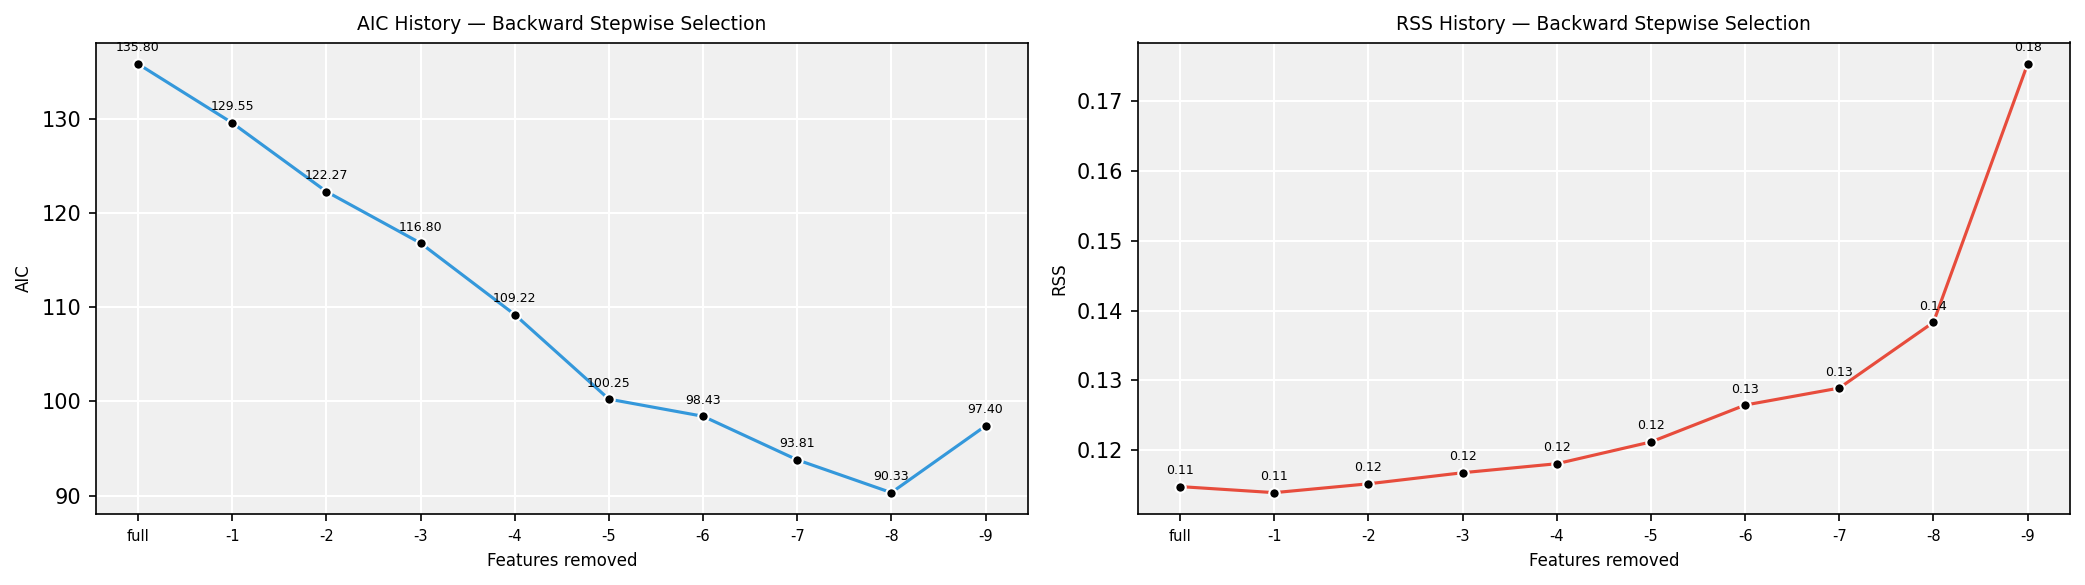

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), dpi=150)
fig.patch.set_facecolor('white')

x = np.arange(len(aic_history))

for ax, history, color, ylabel, title in [
    (ax1, aic_history, '#3498DB', 'AIC', 'AIC History — Backward Stepwise Selection'),
    (ax2, rss_history, '#E74C3C', 'RSS', 'RSS History — Backward Stepwise Selection'),
]:
    ax.set_facecolor('#f0f0f0')
    ax.grid(True, color='white', linestyle='-', linewidth=1)
    ax.set_axisbelow(True)
    ax.plot(x, history, color=color, linewidth=1.5)
    ax.scatter(x, history, color='black', s=25, zorder=5, edgecolors='white')
    ax.set_xticks(x)
    ax.set_xticklabels([f"-{i}" if i > 0 else "full" for i in x], fontsize=7)
    ax.set_xlabel("Features removed", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=9)
    for i, v in enumerate(history):
        ax.annotate(f'{v:.2f}', (i, v), textcoords="offset points",
                    xytext=(0, 6), ha='center', fontsize=6)

plt.tight_layout()
plt.show()

## 2.2 Pin Features for Demo

The selection algorithm above identified `['bp', 'bmi', 's4', 's5']` as the best subset. We pin these four features here to keep the rest of the demo reproducible — running the algorithm again on a different random seed or split could yield a slightly different order.

In [10]:
bestSubsets = ['bp', 'bmi', 's4', 's5']

## 2.3 Forest Plot on Selected Features

The forest plot shows the odds ratio and 95% confidence interval for each category level of the selected features. An odds ratio > 1 suggests higher odds of a `worse` outcome for that group.

/var/folders/6v/j783srq56c39g68f5wpcqj6r0000gn/T/ipykernel_41367/947608805.py:16: RuntimeWarning: divide by zero encountered in divide
  se = np.sqrt(sum(1/contingency.values.flatten()))
/var/folders/6v/j783srq56c39g68f5wpcqj6r0000gn/T/ipykernel_41367/947608805.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  ci_lower = np.exp(np.log(odds_ratio) - 1.96 * se)
/Users/boyuchen/Desktop/Utility Internals/mlops_demo/.venv/lib/python3.11/site-packages/matplotlib/transforms.py:352: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


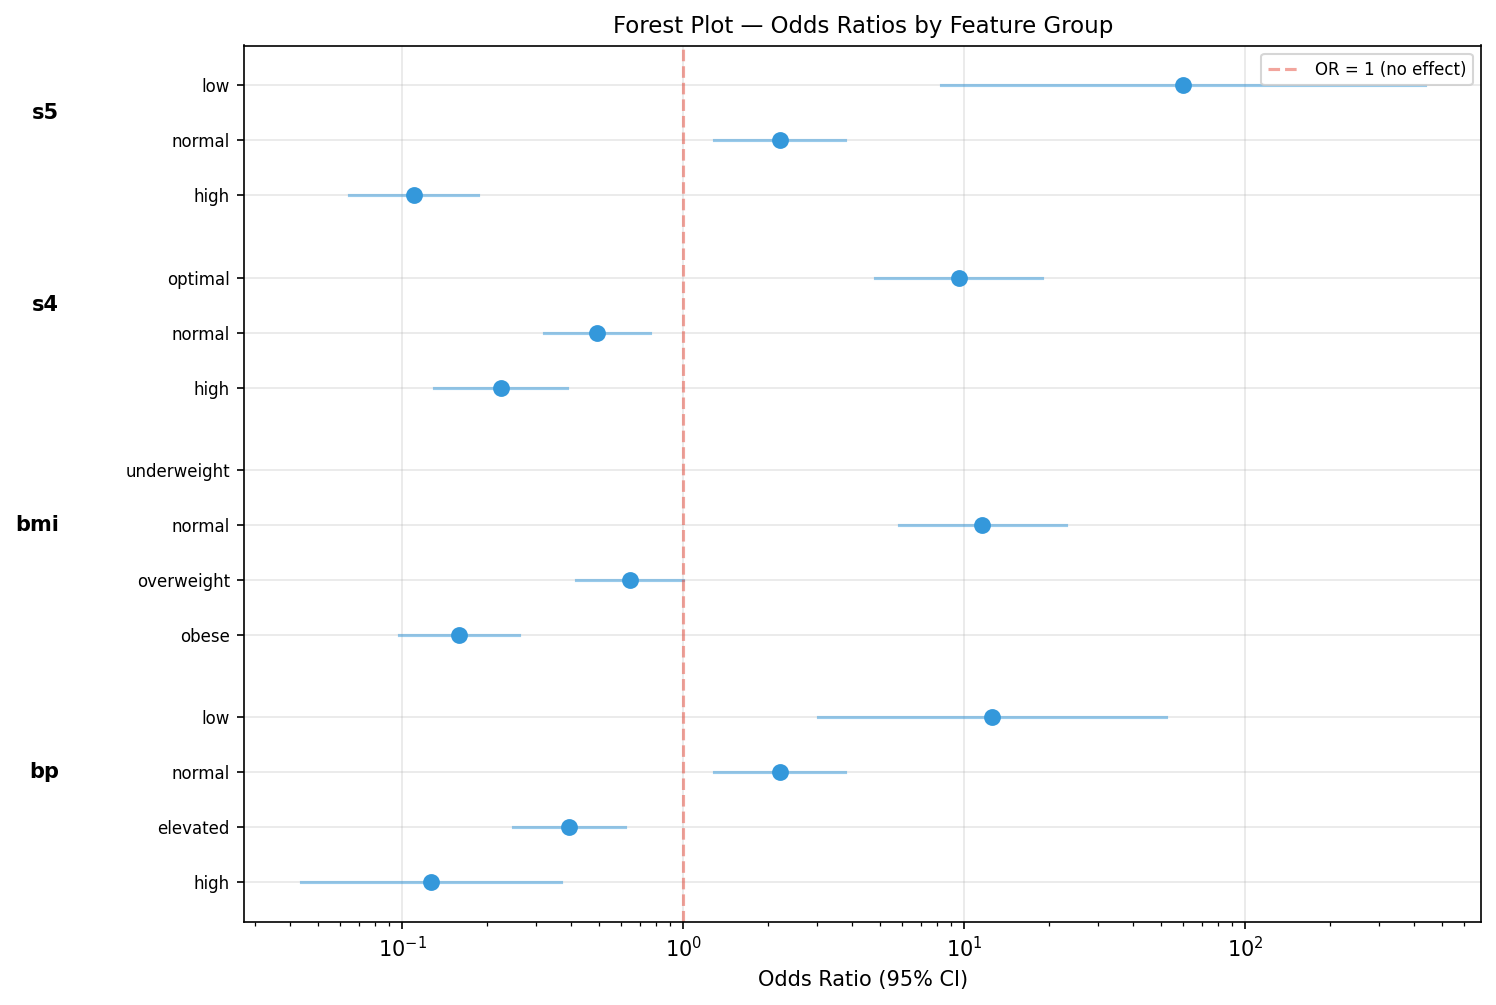

In [11]:
def calculate_odds_ratios(df, target_col='y', reference_value='better'):
    """Calculate odds ratios and confidence intervals for all categorical variables."""
    results = []
    
    for col in df.columns:
        if col != target_col:
            categories = df[col].unique()
            
            for category in categories:
                contingency = pd.crosstab(df[col] == category, 
                                        df[target_col] == reference_value)
                
                odds_ratio, p_value = fisher_exact(contingency)
                
                if odds_ratio > 0:
                    se = np.sqrt(sum(1/contingency.values.flatten()))
                    ci_lower = np.exp(np.log(odds_ratio) - 1.96 * se)
                    ci_upper = np.exp(np.log(odds_ratio) + 1.96 * se)
                else:
                    ci_lower, ci_upper = np.nan, np.nan
                
                results.append({
                    'Feature': col,
                    'Category': category,
                    'Variable': f"{col}_{category}",
                    'Odds_Ratio': odds_ratio,
                    'CI_Lower': ci_lower,
                    'CI_Upper': ci_upper,
                    'P_Value': p_value
                })
    
    return pd.DataFrame(results)

def create_grouped_forest_plot(results_df):
    """Create a forest plot grouped by feature."""
    feature_order = [f for f in ['bp', 'bmi', 's4', 's5'] if f in results_df['Feature'].unique()]
    
    results_df = results_df[results_df['Feature'].isin(feature_order)].copy()
    results_df['Feature_Order'] = results_df['Feature'].map({f: i for i, f in enumerate(feature_order)})
    results_df = results_df.sort_values(['Feature_Order', 'Odds_Ratio'])
    
    fig, ax = plt.subplots(figsize=(10, len(results_df) * 0.4 + len(feature_order) * 0.3), dpi=150)
    
    current_y = 0
    y_positions = []
    y_features = []
    y_feature_labels = []
    
    for feature in feature_order:
        feature_data = results_df[results_df['Feature'] == feature]
        
        if len(feature_data) > 0:
            y_features.append(current_y + len(feature_data) / 2)
            y_feature_labels.append(feature)
            
            for _, row in feature_data.iterrows():
                y_positions.append(current_y)
                ax.scatter(row['Odds_Ratio'], current_y, c='#3498DB', s=50, zorder=5)
                ax.plot([row['CI_Lower'], row['CI_Upper']], [current_y, current_y],
                        color='#3498DB', alpha=0.5)
                ax.text(max(results_df['CI_Upper'].dropna()) * 1.1, current_y,
                        f'OR: {row["Odds_Ratio"]:.2f}  p: {row["P_Value"]:.3f}',
                        verticalalignment='center', fontsize=8)
                current_y += 1
            
            current_y += 0.5
    
    ax.axvline(x=1, color='#E74C3C', linestyle='--', alpha=0.5, label='OR = 1 (no effect)')
    ax.set_xscale('log')
    
    for y, label in zip(y_features, y_feature_labels):
        ax.text(-0.15, y, label, transform=ax.get_yaxis_transform(),
                ha='right', va='center', fontweight='bold', fontsize=10)
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels([row['Category'] for _, row in results_df.iterrows()], fontsize=8)
    ax.set_xlabel('Odds Ratio (95% CI)', fontsize=10)
    ax.set_title('Forest Plot — Odds Ratios by Feature Group', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return plt

df_subset = df_categorized[bestSubsets].copy()
df_subset['y'] = df_categorized['y']

results_or = calculate_odds_ratios(df_subset)
plot = create_grouped_forest_plot(results_or)
plot.show()

## 2.4 Re-encode on Selected Features

We now restrict our feature set to `bestSubsets` and redo the split, oversampling, and encoding pipeline — this time using only the 4 selected features.

In [12]:
X_best = df_categorized[bestSubsets]
y_all_labels = df_categorized['y']

label_encoder = LabelEncoder()
y_encoded_all = label_encoder.fit_transform(y_all_labels)  # better=0, worse=1

onehot = OneHotEncoder(sparse_output=False)
onehot.fit(X_best)
feature_names_encoded_best = onehot.get_feature_names_out(X_best.columns)

X_train_raw2, X_test_raw2, y_train_raw2, y_test_raw2 = train_test_split(
    X_best, y_all_labels, test_size=0.2, random_state=42
)

# Oversample training only
ros2 = RandomOverSampler(random_state=42)
X_train_bal2, y_train_bal2 = ros2.fit_resample(X_train_raw2, y_train_raw2)
X_train_bal2 = pd.DataFrame(X_train_bal2, columns=X_best.columns)

X_train_enc2 = onehot.transform(X_train_bal2)
y_train_enc2 = label_encoder.transform(y_train_bal2)
X_test_enc2 = onehot.transform(X_test_raw2)
y_test_enc2 = label_encoder.transform(y_test_raw2)

print(f"Training samples: {X_train_enc2.shape[0]}, Test samples: {X_test_enc2.shape[0]}")
print(f"Classes: {label_encoder.classes_}")  # 0=better, 1=worse

Training samples: 526, Test samples: 89
Classes: ['better' 'worse']


# 3. GLM Model

## 3.1 Train Logistic Regression

We fit a logistic regression model on the one-hot encoded selected features. Logistic regression is a Generalized Linear Model (GLM) suitable for binary classification — it outputs a probability of belonging to the positive class (`worse`).

In [13]:
initial_model = LogisticRegression(random_state=42, max_iter=200)
initial_model.fit(X_train_enc2, y_train_enc2)
print("Model trained.")

Model trained.


## 3.2 Evaluate on Test Set

We evaluate the model using AUC-ROC (overall discriminative ability), the confusion matrix, and the ROC curve.

In binary classification here:
- **Positive class (1):** `worse` outcome
- **Negative class (0):** `better` outcome

In [14]:
y_pred = initial_model.predict(X_test_enc2)
y_pred_prob = initial_model.predict_proba(X_test_enc2)[:, 1]
conf_matrix = confusion_matrix(y_test_enc2, y_pred)
auc_score = roc_auc_score(y_test_enc2, y_pred_prob)

print(f"AUC-ROC Score: {auc_score:.4f}\n")
print("Confusion Matrix on test set:")
print(f"  True Negative  (predicted better, actual better): {conf_matrix[0][0]}")
print(f"  False Positive (predicted worse,  actual better): {conf_matrix[0][1]}")
print(f"  False Negative (predicted better, actual worse):  {conf_matrix[1][0]}")
print(f"  True Positive  (predicted worse,  actual worse):  {conf_matrix[1][1]}")

AUC-ROC Score: 0.8806

Confusion Matrix on test set:
  True Negative  (predicted better, actual better): 55
  False Positive (predicted worse,  actual better): 13
  False Negative (predicted better, actual worse):  3
  True Positive  (predicted worse,  actual worse):  18


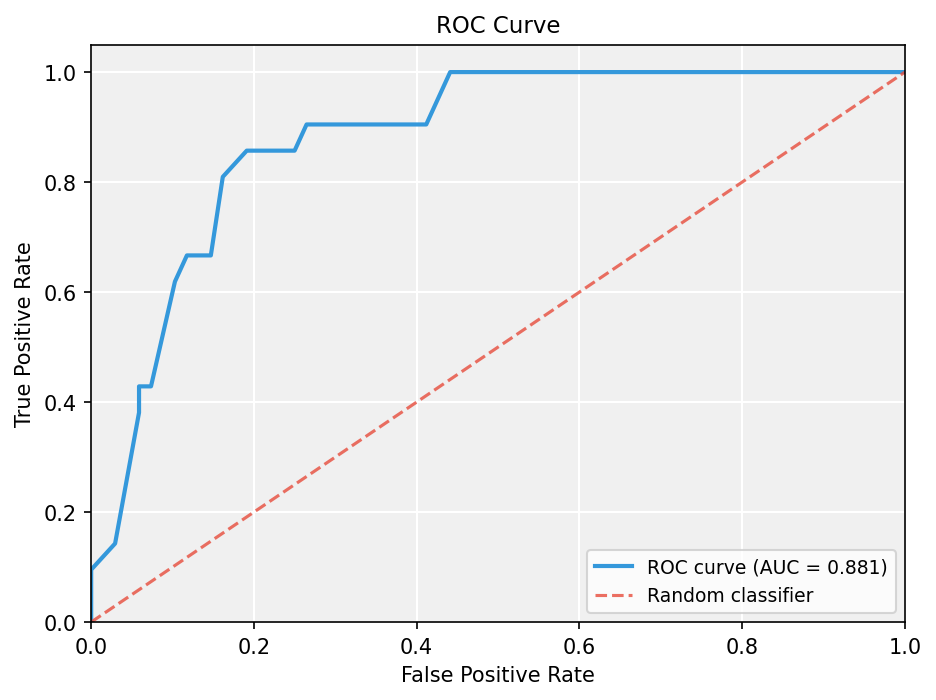

In [15]:
fpr, tpr, thresholds = roc_curve(y_test_enc2, y_pred_prob)

plt.figure(figsize=(7, 5), dpi=150)
ax = plt.gca()
ax.set_facecolor('#f0f0f0')
plt.gcf().patch.set_facecolor('white')
plt.grid(True, color='white', linestyle='-', linewidth=1)
ax.set_axisbelow(True)

plt.plot(fpr, tpr, color='#3498DB', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='#E74C3C', linestyle='--', alpha=0.8, label='Random classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=10)
plt.ylabel('True Positive Rate', fontsize=10)
plt.title('ROC Curve', fontsize=11)
plt.legend(loc='lower right', fontsize=9)
plt.show()

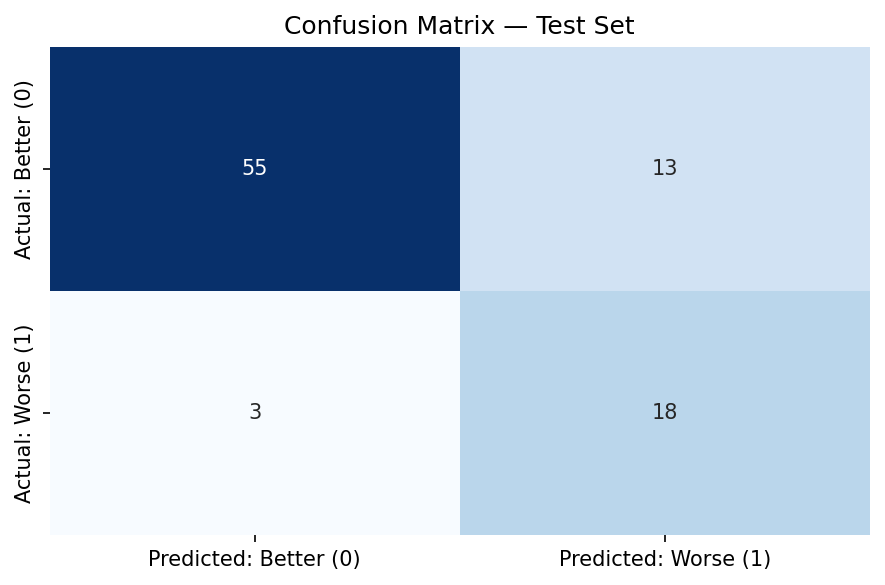

In [16]:
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['Actual: Better (0)', 'Actual: Worse (1)'],
    columns=['Predicted: Better (0)', 'Predicted: Worse (1)']
)
plt.figure(figsize=(6, 4), dpi=150)
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

## 3.3 Error Analysis

We profile the false positives (predicted `worse`, actually `better`) and false negatives (predicted `better`, actually `worse`) by their feature values to understand where the model makes mistakes.

In [17]:
fp_indices = np.where((y_pred == 1) & (y_test_enc2 == 0))[0]
fn_indices = np.where((y_pred == 0) & (y_test_enc2 == 1))[0]

fp_cases = X_test_raw2.iloc[fp_indices].copy()
fp_cases['predicted'] = 'worse'
fp_cases['actual'] = 'better'
fp_cases['pred_probability'] = y_pred_prob[fp_indices]

fn_cases = X_test_raw2.iloc[fn_indices].copy()
fn_cases['predicted'] = 'better'
fn_cases['actual'] = 'worse'
fn_cases['pred_probability'] = y_pred_prob[fn_indices]

print(f"False Positives: {len(fp_indices)}")
print(f"False Negatives: {len(fn_indices)}")

print("\nFalse Positive cases:")
print(fp_cases.to_string())
print("\nFalse Negative cases:")
print(fn_cases.to_string())

feature_importance = pd.DataFrame({
    'feature': feature_names_encoded_best,
    'coefficient': initial_model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\nFeature coefficients (descending):")
print(feature_importance.to_string())

False Positives: 13
False Negatives: 3

False Positive cases:
           bp         bmi       s4      s5 predicted  actual  pred_probability
72   elevated  overweight   normal    high     worse  better          0.640233
30     normal       obese  optimal  normal     worse  better          0.515552
333  elevated  overweight   normal    high     worse  better          0.640233
311       low       obese     high    high     worse  better          0.567274
15   elevated      normal     high    high     worse  better          0.503422
0    elevated       obese   normal    high     worse  better          0.791154
320  elevated  overweight     high    high     worse  better          0.829966
56     normal       obese   normal    high     worse  better          0.683708
409  elevated  overweight     high    high     worse  better          0.829966
25     normal  overweight   normal    high     worse  better          0.503836
42   elevated  overweight   normal  normal     worse  better         

## 3.4 Chi-Square Independence Tests

We test whether each selected feature is statistically independent of the outcome. The null hypothesis H₀ is that there is no association between the feature and the outcome. A p-value below 0.01 gives us strong evidence to reject H₀.

In [18]:
def get_chi_stats(df, col1, col2, p_threshold=0.01):
    contingency_table = pd.crosstab(df[col1], df[col2])
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    result = "Reject H0 - significant association" if p_value < p_threshold else "Fail to reject H0 - no significant association"
    print(f"{col1} vs {col2}: chi2={chi2_stat:.3f}, p={p_value:.4f} -> {result}")

df_complete = X_train_raw2.copy()
df_complete['y'] = y_train_raw2.values

for feature in bestSubsets:
    get_chi_stats(df_complete, feature, 'y')

bp vs y: chi2=41.924, p=0.0000 -> Reject H0 - significant association
bmi vs y: chi2=77.869, p=0.0000 -> Reject H0 - significant association
s4 vs y: chi2=52.026, p=0.0000 -> Reject H0 - significant association
s5 vs y: chi2=64.691, p=0.0000 -> Reject H0 - significant association


## 3.5 Feature Correlation

We compute the correlation matrix using the **original numeric values** from the diabetes dataset. The categorized features are ordinal and not suitable for Pearson correlation, so we revert to the continuous representation for this analysis only.

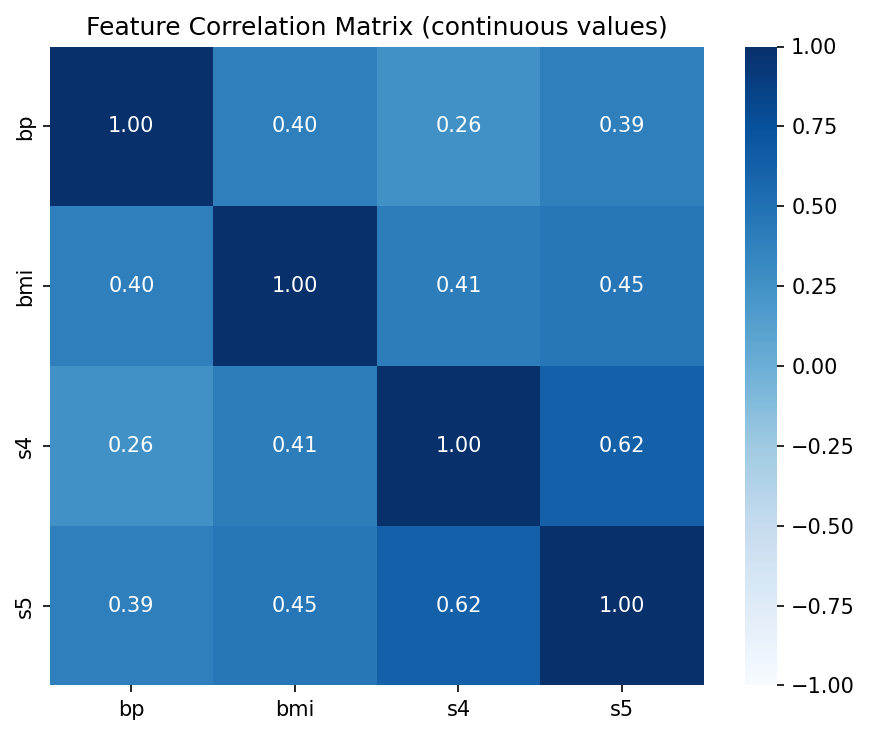

In [19]:
diabetes = load_diabetes()
X_norm = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)[bestSubsets]
correlation_matrix = X_norm.corr()

plt.figure(figsize=(6, 5), dpi=150)
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', vmin=-1, vmax=1, fmt='.2f')
plt.title('Feature Correlation Matrix (continuous values)')
plt.tight_layout()
plt.show()

# 4. Risk Scoring

## 4.1 Score Transformation

Each category level of each feature is assigned a score between 0 and 1000 based on the logistic regression coefficients. The formula normalizes each feature's coefficients to a 0–1000 range:

$$S_{ij} = 1000 \frac{\hat{\beta}_{ij} - \min(\hat{\beta}_i)}{\max(\hat{\beta}_i) - \min(\hat{\beta}_i)}$$

This makes the scores interpretable: a score of 1000 on a feature means that category is the highest-risk level for that predictor.

In [20]:
def calculate_scores(coefficients, X_categorized, onehot_encoder):
    coeffs = {}
    scores = {}
    feature_names_enc = onehot_encoder.get_feature_names_out(X_categorized.columns)
    
    for feature in X_categorized.columns:
        if pd.api.types.is_categorical_dtype(X_categorized[feature]):
            feature_levels = X_categorized[feature].cat.categories
        else:
            feature_levels = X_categorized[feature].unique()
        
        feature_coeffs = []
        for level in feature_levels:
            encoded_feature = f"{feature}_{level}"
            if encoded_feature in feature_names_enc:
                idx = np.where(feature_names_enc == encoded_feature)[0][0]
                feature_coeffs.append(coefficients[idx])
        
        min_coeff = np.min(feature_coeffs)
        max_coeff = np.max(feature_coeffs)
        
        feature_scores = {}
        feature_coeffs_dict = {}
        for level, coeff in zip(feature_levels, feature_coeffs):
            feature_coeffs_dict[level] = coeff
            score = 1000 * (coeff - min_coeff) / (max_coeff - min_coeff) if max_coeff != min_coeff else 0
            feature_scores[level] = score
        
        coeffs[feature] = feature_coeffs_dict
        scores[feature] = feature_scores
    
    return coeffs, scores

coefficients = initial_model.coef_[0]
coeffs, scores = calculate_scores(coefficients, X_best, onehot)

for feature, feature_scores in scores.items():
    print(f"\n{feature}:")
    for level, score in feature_scores.items():
        print(f"  {level}: {score:.1f}")


bp:
  low: 0.0
  normal: 440.1
  elevated: 603.8
  high: 1000.0

bmi:
  underweight: 482.4
  normal: 0.0
  overweight: 675.4
  obese: 1000.0

s4:
  optimal: 0.0
  normal: 296.7
  high: 1000.0

s5:
  low: 0.0
  normal: 893.7
  high: 1000.0


/var/folders/6v/j783srq56c39g68f5wpcqj6r0000gn/T/ipykernel_41367/228215847.py:7: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X_categorized[feature]):


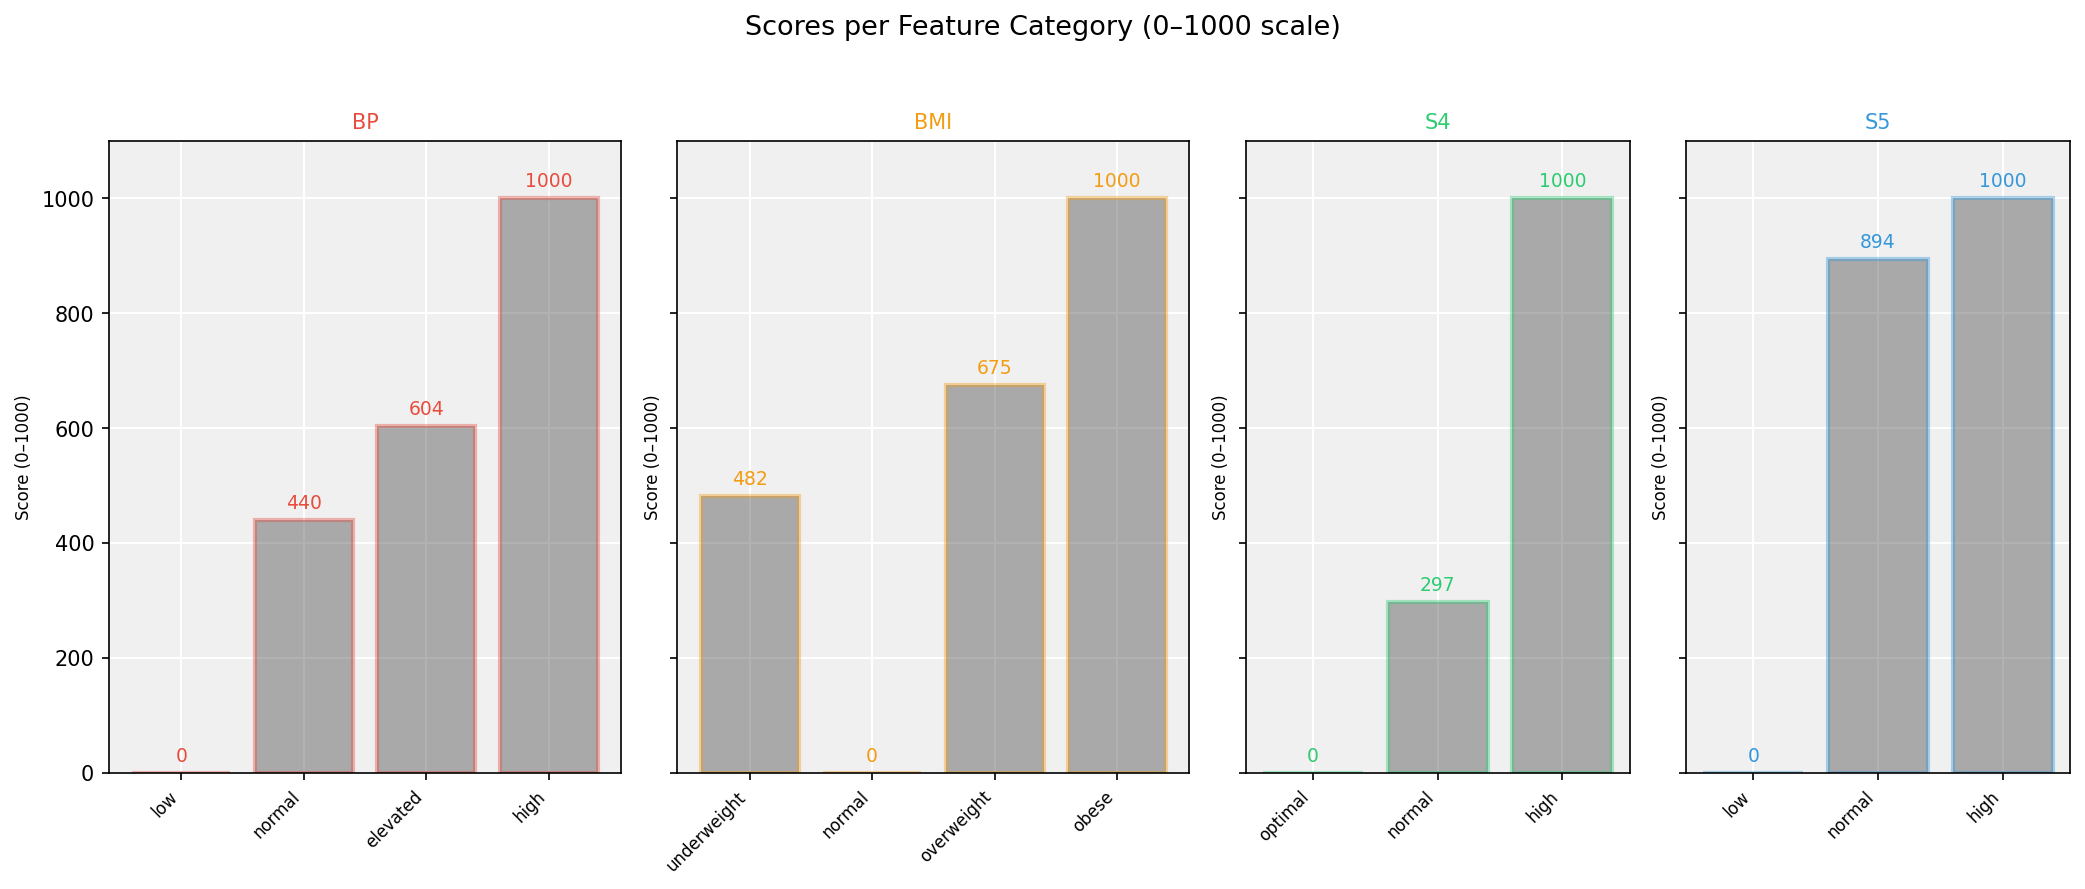

In [21]:
widths = [len(data) for data in scores.values()]
width_ratios = [w / min(widths) for w in widths]

fig, axes = plt.subplots(1, len(scores), figsize=(14, 6), sharey=True, dpi=150,
                         gridspec_kw={'width_ratios': width_ratios})
fig.suptitle("Scores per Feature Category (0\u20131000 scale)", fontsize=13)
colors = ['#E74C3C', '#F39C12', '#2ECC71', '#3498DB']
bar_width = 0.8

for i, (category, data) in enumerate(scores.items()):
    labels, values = zip(*data.items())
    x = np.arange(len(labels))
    axes[i].set_facecolor('#f0f0f0')
    axes[i].grid(True, color='white', linestyle='-', linewidth=1)
    axes[i].set_axisbelow(True)
    axes[i].bar(x, values, bar_width, color='#404040',
                edgecolor=colors[i % len(colors)], linewidth=2, alpha=0.4)
    axes[i].set_title(category.upper(), color=colors[i % len(colors)], fontsize=10)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    axes[i].set_ylim(0, 1100)
    axes[i].set_ylabel('Score (0\u20131000)', fontsize=8)
    for j, val in enumerate(values):
        axes[i].text(j, val + 20, f"{val:.0f}", ha='center',
                     color=colors[i % len(colors)], fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 4.2 Retrain on Scores and Derive Weights

We replace each patient's feature values with their corresponding scores, scale the result, and retrain the logistic regression. The new model coefficients represent each feature's contribution to risk — normalized to weights that sum to 1.

In [22]:
X_scores = X_best.copy()
for feature in scores.keys():
    X_scores[feature] = X_scores[feature].map(scores[feature])
X_scores = X_scores.astype(float)

scaler = StandardScaler()
X_scores_scaled = scaler.fit_transform(X_scores)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scores_scaled, y_encoded_all, test_size=0.2, random_state=42
)

retrained_model = LogisticRegression(random_state=42, max_iter=200)
retrained_model.fit(X_train_s, y_train_s)
beta_i = retrained_model.coef_[0]
w_i = beta_i / np.sum(beta_i)

print("Feature weights:")
for feat, w in zip(bestSubsets, w_i):
    print(f"  {feat}: {w:.4f}")

Feature weights:
  bp: 0.2624
  bmi: 0.2856
  s4: 0.1378
  s5: 0.3142


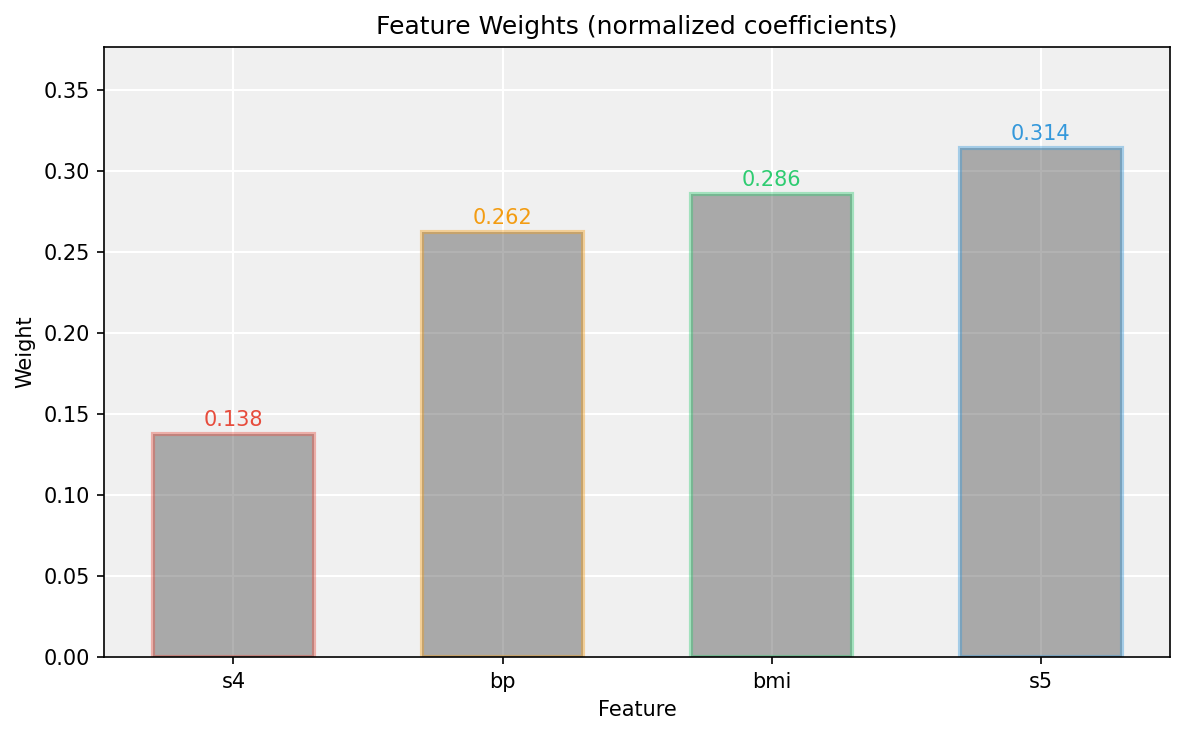

In [23]:
sorted_pairs = sorted(zip(w_i, bestSubsets))
weights_sorted, categories_sorted = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.set_facecolor('#f0f0f0')
fig.patch.set_facecolor('white')
ax.grid(True, color='white', linestyle='-', linewidth=1)
ax.set_axisbelow(True)

colors_w = ['#E74C3C', '#F39C12', '#2ECC71', '#3498DB']
x = np.arange(len(weights_sorted))
bars = ax.bar(x, weights_sorted, 0.6, color='#404040',
              edgecolor=colors_w, linewidth=2, alpha=0.4)

ax.set_title("Feature Weights (normalized coefficients)", fontsize=12)
ax.set_xlabel("Feature", fontsize=10)
ax.set_ylabel("Weight", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(categories_sorted, fontsize=10)
ax.set_ylim(0, max(weights_sorted) * 1.2)

for i, w in enumerate(weights_sorted):
    ax.text(i, w + 0.005, f"{w:.3f}", ha='center', color=colors_w[i], fontsize=10)

plt.tight_layout()
plt.show()

## 4.3 Composite Risk Score

Each patient's final risk score is the weighted sum of their feature scores, scaled to a 0–100 range:

$$RS_i = \frac{1}{10} \sum_j S_{ij} \cdot w_j$$

A higher score indicates higher predicted risk of a `worse` outcome.

In [24]:
RS_i = np.sum(X_scores.values * w_i / 10, axis=1)
R = X_scores.copy()
R['RS'] = RS_i
R['y'] = y_encoded_all

print(f"Risk score range: {RS_i.min():.1f} - {RS_i.max():.1f}")
print(f"Mean: {RS_i.mean():.1f}, Median: {np.median(RS_i):.1f}")
R.head()

Risk score range: 0.0 - 100.0
Mean: 51.8, Median: 54.8


,bp,bmi,s4,s5,RS,y
0,603.751986,1000.00000,296.728041,1000.000000,79.910567,0
1,440.131202,0.00000,0.000000,0.000000,11.549237,0
2,603.751986,1000.00000,296.728041,893.728277,76.571901,0
3,440.131202,675.35386,296.728041,1000.000000,66.344425,0
4,603.751986,0.00000,296.728041,0.000000,19.931894,0


## 4.4 Risk Score Analysis

We analyze the distribution of risk scores overall and stratified by outcome class. The bucket chart shows what proportion of each outcome class falls into each 10-point risk band.

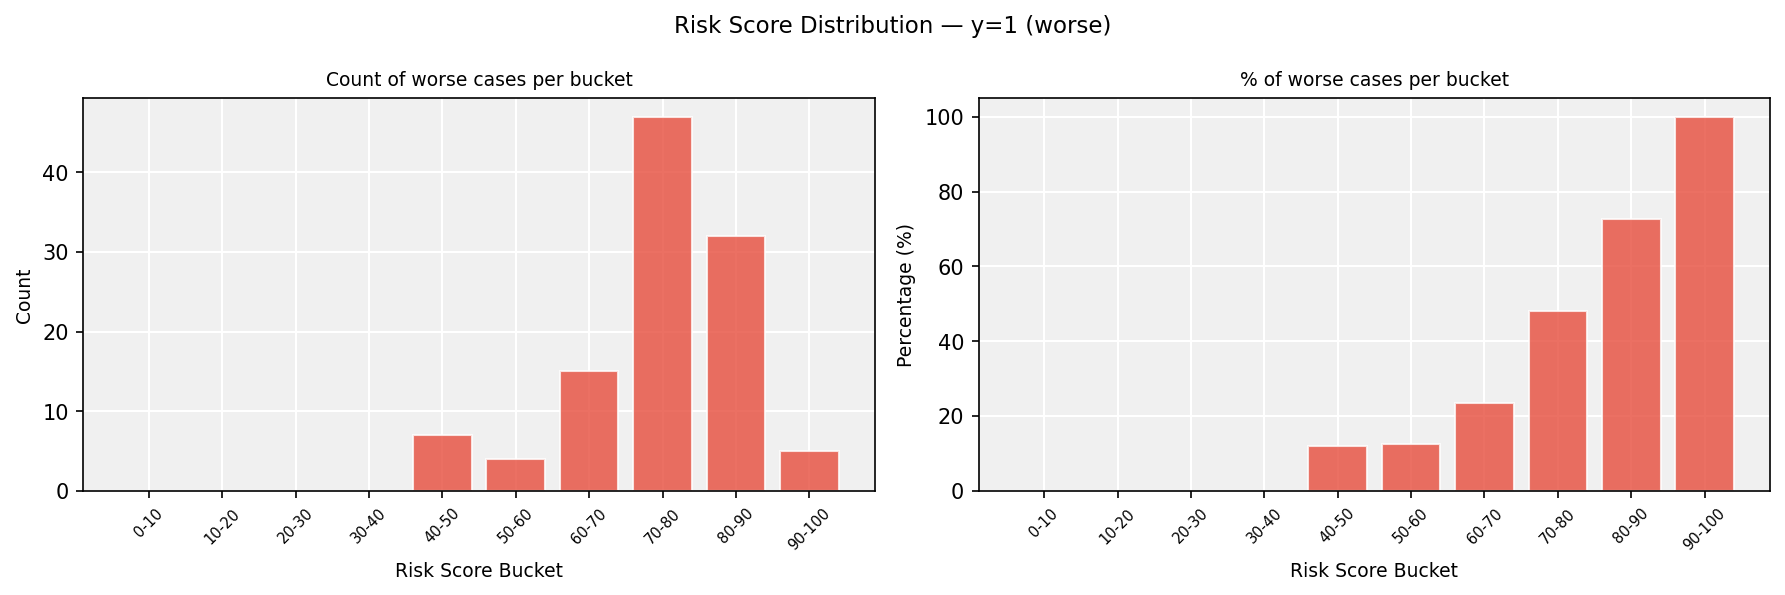

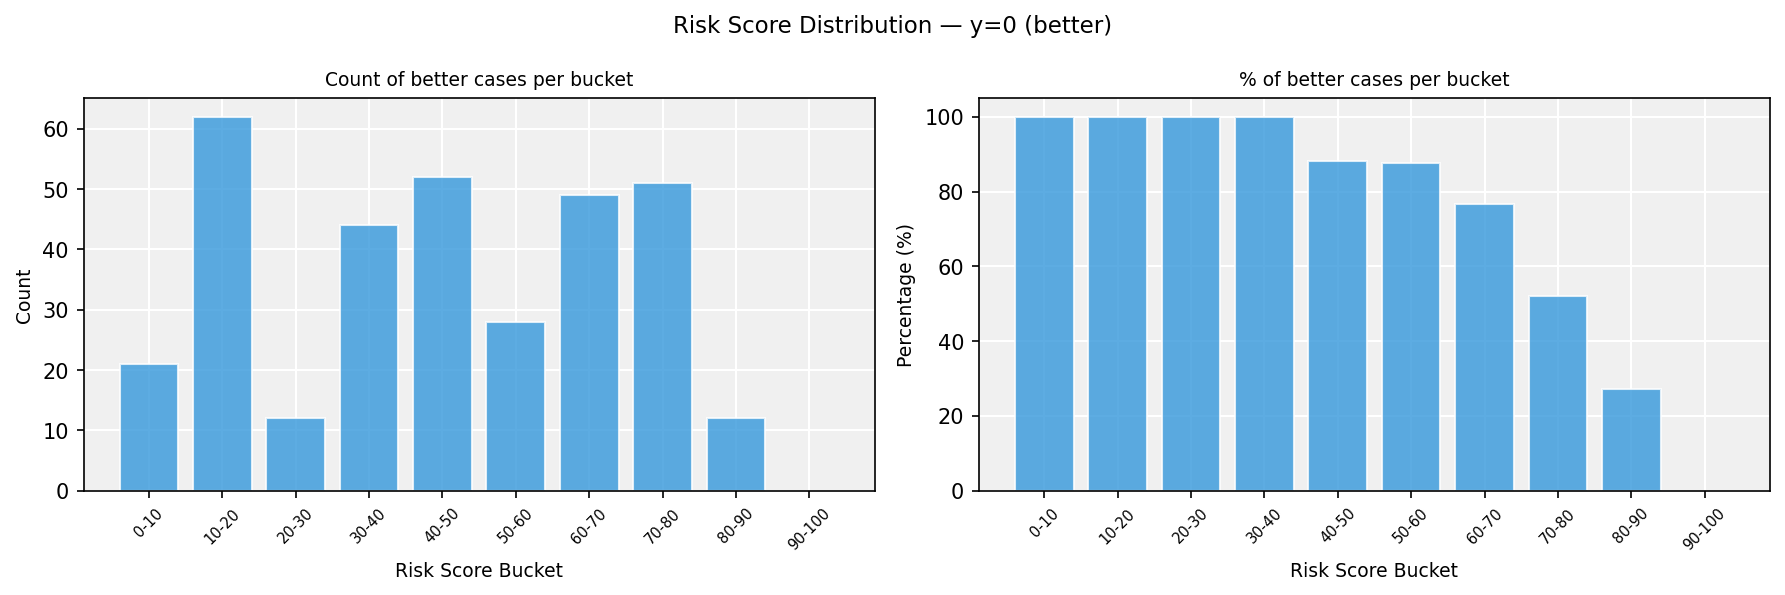

In [25]:
def generateBucketChart(R, y_type, step=10):
    target = 'better' if y_type == 0 else 'worse'
    color = '#E74C3C' if y_type == 1 else '#3498DB'

    bins = list(range(0, 101, step))
    labels = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]
    R = R.copy()
    R['bucket'] = pd.cut(R['RS'], bins=bins, labels=labels, right=False)
    total_counts = R['bucket'].value_counts().sort_index()
    y_counts = R[R['y'] == y_type]['bucket'].value_counts().sort_index()

    y_ratios = pd.Series(index=labels, dtype=float)
    for bucket in labels:
        total = total_counts.get(bucket, 0)
        count = y_counts.get(bucket, 0)
        y_ratios[bucket] = count / total if total > 0 else 0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=150)
    fig.patch.set_facecolor('white')
    fig.suptitle(f'Risk Score Distribution \u2014 y={y_type} ({target})', fontsize=11)
    x = np.arange(len(labels))

    for ax in [ax1, ax2]:
        ax.set_facecolor('#f0f0f0')
        ax.grid(True, color='white', linestyle='-', linewidth=1)
        ax.set_axisbelow(True)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, fontsize=7)
        ax.set_xlabel("Risk Score Bucket", fontsize=9)

    ax1.bar(x, y_counts.reindex(labels, fill_value=0), color=color, alpha=0.8, edgecolor='white')
    ax1.set_title(f'Count of {target} cases per bucket', fontsize=9)
    ax1.set_ylabel('Count', fontsize=9)

    ax2.bar(x, 100 * y_ratios, color=color, alpha=0.8, edgecolor='white')
    ax2.set_title(f'% of {target} cases per bucket', fontsize=9)
    ax2.set_ylabel('Percentage (%)', fontsize=9)

    plt.tight_layout()
    plt.show()

generateBucketChart(R, 1)
generateBucketChart(R, 0)

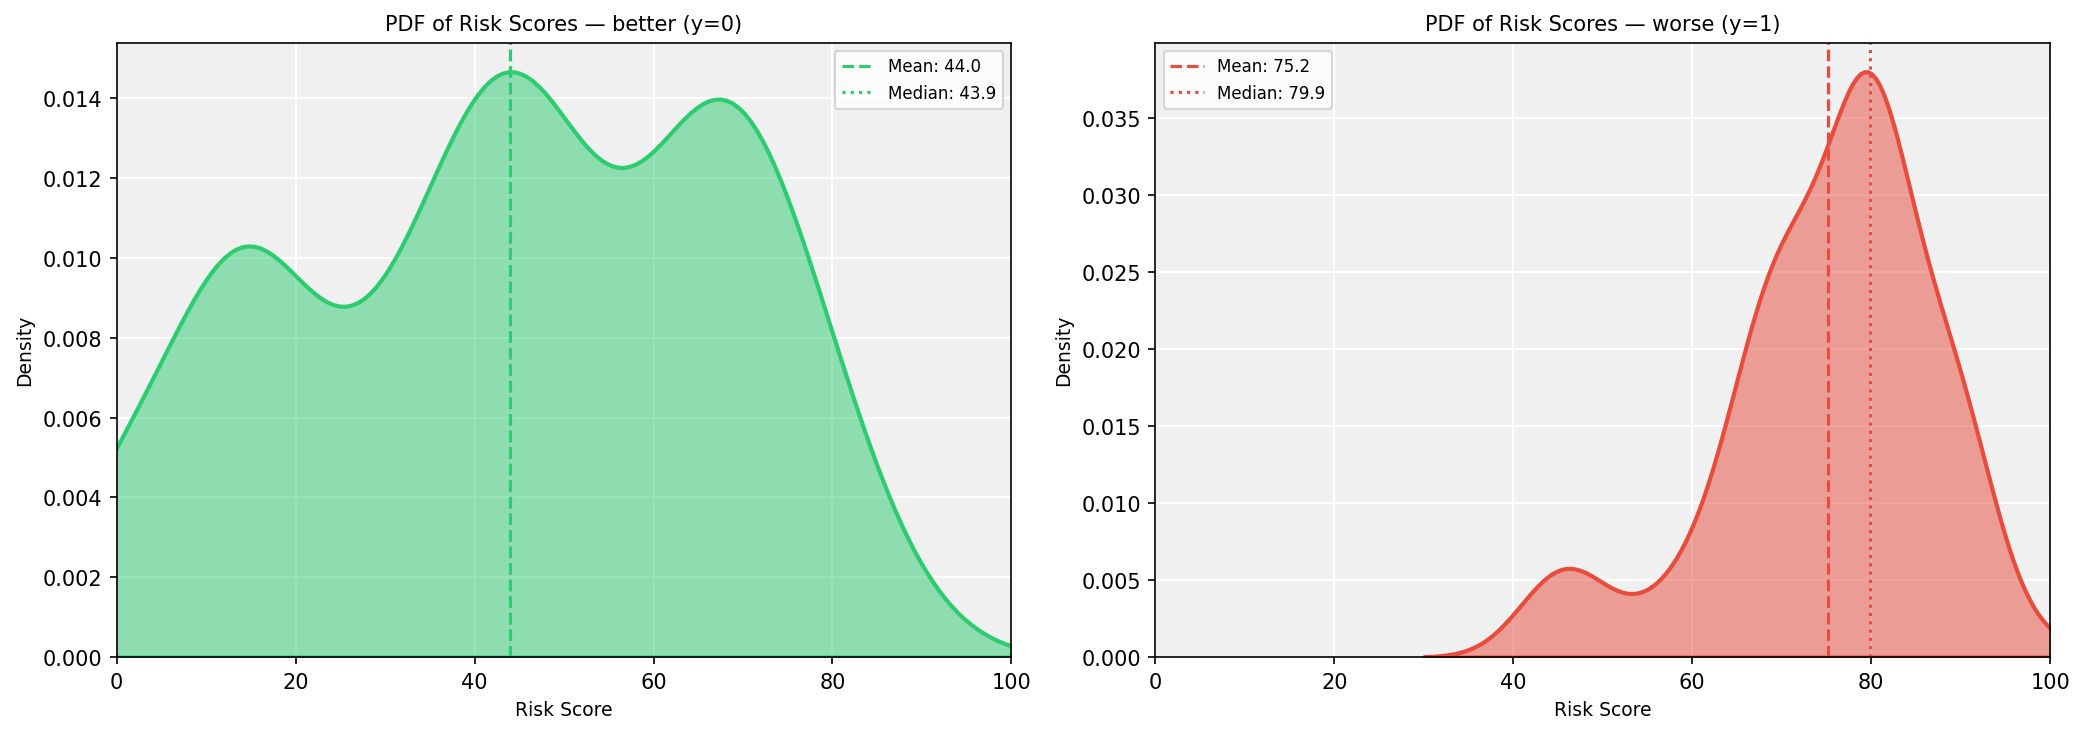


Risk Score Summary:
  worse (y=1): mean=75.2, median=79.9, std=11.7
  better (y=0): mean=44.0, median=43.9, std=23.9


In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
fig.patch.set_facecolor('white')

rs_y0 = R[R['y'] == 0]['RS']
rs_y1 = R[R['y'] == 1]['RS']

for ax, rs, color, label in [
    (ax1, rs_y0, '#2ECC71', 'better (y=0)'),
    (ax2, rs_y1, '#E74C3C', 'worse (y=1)'),
]:
    ax.set_facecolor('#f0f0f0')
    sns.kdeplot(data=rs, color=color, fill=True, alpha=0.5, linewidth=2, ax=ax)
    ax.axvline(x=rs.mean(), color=color, linestyle='--', linewidth=1.5, label=f'Mean: {rs.mean():.1f}')
    ax.axvline(x=rs.median(), color=color, linestyle=':', linewidth=1.5, label=f'Median: {rs.median():.1f}')
    ax.set_title(f'PDF of Risk Scores \u2014 {label}', fontsize=10)
    ax.set_xlabel('Risk Score', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.set_xlim(0, 100)
    ax.legend(fontsize=8)
    ax.grid(True, color='white', linestyle='-', linewidth=1)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("\nRisk Score Summary:")
print(f"  worse (y=1): mean={rs_y1.mean():.1f}, median={rs_y1.median():.1f}, std={rs_y1.std():.1f}")
print(f"  better (y=0): mean={rs_y0.mean():.1f}, median={rs_y0.median():.1f}, std={rs_y0.std():.1f}")